# 🧠 Entrenamiento de Clasificadores BiLSTM con Gated Pooling

Este notebook tiene como objetivo principal el entrenamiento y comparación de diferentes arquitecturas basadas en **LSTM Bidireccionales (BiLSTM)** para la clasificación binaria de secuencias, utilizando embeddings pre-calculados de ProtFlash (dimensión 768) y enriquecimiento guiado por AAontology. 📊

## 🛠️ Componentes Principales:
- **🏗️ Arquitecturas Evaluadas**: Se comparan 4 configuraciones: `Gated_BiLSTM_Baseline`, `Gated_BiLSTM_Deep`, `Gated_BiLSTM_Large` y `Gated_LSTM_Uni` (unidireccional).
- **🧩 Integración Bioinformática**: Uso de `AAontologyGatedPooler` para ponderar residuos según 8 perfiles fisicoquímicos z-scored antes de pasar por la LSTM.
- **📉 Pipeline de Entrenamiento Robusto**: Carga de datasets serializados (`.pt`), manejo de desbalance con `pos_weight` en `BCEWithLogitsLoss`, `Early Stopping` (`patience=12`), `ReduceLROnPlateau` y registro de métricas (Acc, F1, MCC, ROC/PR-AUC).
- **⚡ Entorno**: Ejecución optimizada para GPU (Tesla T4) con gradient clipping y gestión determinista de semillas.

## 📦 Importación de librerías y entorno

In [1]:
import os
import json
import random
import time
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    matthews_corrcoef, confusion_matrix
)
import matplotlib.pyplot as plt

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.10.0+cu128
cuda available: True


## ⚙️ Configuración de rutas e hiperparámetros BiLSTM

In [2]:
# ========== PATHS ==========
DATA_DIR = Path("/kaggle/input/datasets/user/dataset-created")
OUT_DIR = Path("/kaggle/working/BiLSTM_Results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PT  = DATA_DIR / "train_dataset.pt"
VAL_PT    = DATA_DIR / "val_dataset.pt"
AAONTOLOGY_PATH = "/kaggle/input/datasets/user/aantology/aa_ontology_zscored.pt"

# ========== HYPERPARAMETERS ==========
SEED        = 31
BATCH_SIZE  = 32
MAX_EPOCHS  = 100
PATIENCE    = 12
MIN_DELTA   = 1e-4
INPUT_DIM   = 768
L_MAX       = 100
N_AA        = 20
N_CAT       = 8

# ========== ARCHITECTURES ==========
ARCHITECTURES = [
    {
        "name": "Gated_BiLSTM_Small",
        "hidden_size": 128,
        "num_layers": 1,
        "mlp_hidden": [128],
        "dropout": 0.3,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "Gated_BiLSTM_Medium",
        "hidden_size": 256,
        "num_layers": 2,
        "mlp_hidden": [128],
        "dropout": 0.4,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "Gated_BiLSTM_Large",
        "hidden_size": 512,
        "num_layers": 2,
        "mlp_hidden": [256, 128],
        "dropout": 0.5,
        "lr": 5e-4,
        "weight_decay": 1e-4,
    },
]

print(f"Architectures to compare: {len(ARCHITECTURES)}")
for cfg in ARCHITECTURES:
    print(f"  - {cfg['name']}: hidden={cfg['hidden_size']}, layers={cfg['num_layers']}, dropout={cfg['dropout']}")

Architectures to compare: 3
  - Gated_BiLSTM_Small: hidden=128, layers=1, dropout=0.3
  - Gated_BiLSTM_Medium: hidden=256, layers=2, dropout=0.4
  - Gated_BiLSTM_Large: hidden=512, layers=2, dropout=0.5


## 🖥️ Semilla para reproducibilidad y detección de dispositivo

In [3]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 🔬 Carga del tensor AAontology

In [4]:
# Carga el tensor (20, 8) precomputado con z-scores por categoría
if Path(AAONTOLOGY_PATH).exists():
    aa_data = torch.load(AAONTOLOGY_PATH, map_location="cpu", weights_only=True)
    AAONTOLOGY_ZSCORED = aa_data["tensor"]  # (20, 8)
    AA_ORDER = aa_data["amino_acids"]        # list de 20 AA
    USED_CATEGORIES = aa_data["categories"]    # 8 categorías
else:
    raise FileNotFoundError(f"No se encontró {AAONTOLOGY_PATH}. Genera el tensor primero.")

# Mapeo AA → índice para lookup rápido
AA_TO_IDX = {aa: i for i, aa in enumerate(AA_ORDER)}
print(f"AAontology tensor: {AAONTOLOGY_ZSCORED.shape}")
print(f"Categorías: {USED_CATEGORIES}")

AAontology tensor: torch.Size([21, 8])
Categorías: ['ASA/Volume', 'Composition', 'Conformation', 'Energy', 'Polarity', 'Shape', 'Structure-Activity', 'Others']


## 📂 Definición de la clase `AMPDataset`

In [5]:
class AMPDataset(Dataset):
    """
    Estructura por muestra:
        X:   torch.FloatTensor (L_max, 768)  — ProtFlash embeddings
        G:   torch.FloatTensor (L_max, 8)    — AAontology features
        M:   torch.FloatTensor (L_max,)      — binary mask
        seq: str                             — AA sequence (for AAontology)
        y:   torch.FloatTensor (1,)          — label
    """
    def __init__(self, X, G, M, sequences, labels):
        self.X = torch.from_numpy(X).float()          # (N, L_max, 768)
        self.G = torch.from_numpy(G).float()          # (N, L_max, 8)
        assert self.G.shape[-1] == 8, f"Se esperaban 8 categorías de ontología, pero G tiene shape {self.G.shape}"
        self.M = torch.from_numpy(M).float()          # (N, L_max)
        self.sequences = list(sequences)
        self.y = torch.from_numpy(labels).float().unsqueeze(1)  # (N, 1)

        assert len(self.X) == len(self.G) == len(self.M) == len(self.seqs) == len(self.y), \
            "Las longitudes de X, G, M, seqs y y no coinciden."

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "X": self.X[idx],           # (L_max, 768)
            "G": self.G[idx],           # (L_max, 8)
            "M": self.M[idx],           # (L_max,)
            "seq": self.sequences[idx],      # str (Ej: "MKLL...")
            "y": self.y[idx]            # (1,)
        }

## 💾 Función de carga de datasets pre-serializados

In [6]:
def load_pt_dataset(pt_path):
    pt_path = Path(pt_path)
    if not pt_path.exists(): raise FileNotFoundError
    return torch.load(pt_path, map_location="cpu", weights_only=False)

## 📥 Carga de splits de entrenamiento y validación

In [7]:
print("Loading datasets:")
train_ds = load_pt_dataset(TRAIN_PT)
val_ds   = load_pt_dataset(VAL_PT)

print(f"\n🔍 Test __len__:")
print(f"   train_ds: {len(train_ds)} muestras")
print(f"   val_ds  : {len(val_ds)} muestras")

print(f"\n🔍 Test __getitem__[0]:")
sample = train_ds[0]
keys = ['X', 'G', 'M', 'seq', 'y']

for k, v in zip(keys, sample):
    if isinstance(v, torch.Tensor):
        print(f"   {k}: {tuple(v.shape)} {v.dtype}")
    else:
        print(f"   {k}: {type(v).__name__} = '{str(v)[:50]}'")

Loading datasets:

🔍 Test __len__:
   train_ds: 13826 muestras
   val_ds  : 3614 muestras

🔍 Test __getitem__[0]:
   X: str = 'X'
   G: str = 'G'
   M: str = 'M'
   seq: str = 'seq'
   y: str = 'y'


## 🤝 Función de colación (`collate_fn`)

In [8]:
def collate_fn(batch):
    """
    Collate function construye dinámicamente los perfiles de AAontology (B, L, 8)
    a partir de las secuencias.
    """
    if isinstance(batch[0], dict):
        # 1. Extraer tensores base
        X = torch.stack([item['X'] for item in batch])   # (B, L, 768)
        M = torch.stack([item['M'] for item in batch])   # (B, L)
        y = torch.stack([item['y'] for item in batch])   # (B, 1)
        seqs = [item['seq'] for item in batch]           # List[str]
        
        # 2. Contruir perfiles de ontología
        B, L, _ = X.shape
        # Inicializamos el tensor de ontología en ceros
        ont_profiles = torch.zeros(B, L, 8, dtype=X.dtype, device=X.device)
        
        for i, seq in enumerate(seqs):
            for j, aa in enumerate(seq[:L]):
                if aa in AA_TO_IDX:
                    # Asignamos las 8 categorías z-scored para este aminoácido
                    ont_profiles[i, j] = AAONTOLOGY_ZSCORED[AA_TO_IDX[aa]]
        return X, ont_profiles, M, seqs, y
    else:
        raise TypeError("Batch fallido: se esperaba un diccionario por muestra.")

## 🚚 Creación de DataLoaders

In [9]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"\n✅ Batches: train={len(train_loader)}, val={len(val_loader)}")

X_b, G_b, M_b, seq_b, y_b = next(iter(train_loader))
print(f"   ✅ X_b: {tuple(X_b.shape)} | G_b: {tuple(G_b.shape)} | seq_b: {len(seq_b)}")


✅ Batches: train=433, val=113
   ✅ X_b: (32, 100, 768) | G_b: (32, 100, 8) | seq_b: 32


## 🧩 Capa `AAontologyGatedPooler` diferenciable

In [10]:
class AAontologyGatedPooler(nn.Module):
    """
    Gated Pooling que combina el contexto de ProtFlash (X) 
    con el prior bioquímico de AAontology (P).
    """
    def __init__(self, input_dim: int = 768, n_categories: int = 8):
        super().__init__()
        self.n_categories = n_categories
        
        # Proyectamos la ontología (8 -> 64)
        self.ont_proj = nn.Linear(n_categories, 64) 
        
        # Red de gating CONSCIENTE DEL CONTEXTO (768 + 64 = 832)
        self.gating_mlp = nn.Sequential(
            nn.Linear(input_dim + 64, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
        
        self.proj = nn.Linear(input_dim, input_dim)

    def forward(self, X: torch.Tensor, G: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        """
        X: (B, L, 768) - ProtFlash
        G: (B, L, 8)   - AAontology precalculada (viene del Dataset)
        M: (B, L)      - Mask
        """
        # 1. Proyectar ontología (B, L, 64)
        ont_proj = self.ont_proj(G) 
        
        # 2. CONCATENAR Contexto + Ontología (B, L, 832)
        combined_features = torch.cat([X, ont_proj], dim=-1)
        
        # 3. Calcular gates (B, L, 1)
        gates = self.gating_mlp(combined_features) * M.unsqueeze(-1)
        
        # 4. Agregación ponderada
        weighted = gates * self.proj(X) * M.unsqueeze(-1)
        return weighted.sum(dim=1) / (M.sum(dim=1, keepdim=True) + 1e-8)

## 🏗️ Arquitectura `GatedBiLSTMClassifier` y Verificación

In [11]:
# ========== MODELO BiLSTM + GATED POOLER ==========
class GatedBiLSTMClassifier(nn.Module):
    """
    BiLSTM classifier con Context-Aware AAontology Gated Pooling.
    Flujo: GatedPooler agrega secuencia → BiLSTM procesa secuencia → clasifica
    """
    def __init__(self, input_dim: int, hidden_size: int, num_layers: int, mlp_hidden: List[int], dropout: float = 0.3, n_categories: int = 8):
        super().__init__()
        
        # 1. Pooler CONSCIENTE DEL CONTEXTO (Estrategia 1)
        self.pooler = AAontologyGatedPooler(input_dim=input_dim, n_categories=n_categories)
        
        # 2. BiLSTM: los canales de salida serán hidden_size * 2
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        
        # 3. MLP Clasificador
        # Max + Avg pool_dim (h*2) * 2 = h*4
        lstm_out_dim = hidden_size * 4  
        # La entrada al MLP será: LSTM_Feats + Global Context (input_dim) + Local Physical (input_dim)
        clf_in_dim = lstm_out_dim + input_dim + input_dim 
        
        layers = []
        for h_dim in mlp_hidden:
            layers.append(nn.Linear(clf_in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            clf_in_dim = h_dim
            
        self.mlp = nn.Sequential(*layers)
        self.classifier = nn.Linear(clf_in_dim, 1)

    def forward(self, X: torch.Tensor, ont_profiles: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        """
        X: (B, L, 768) - ProtFlash embeddings
        ont_profiles: (B, L, 8) - AAontology per-residue features
        M: (B, L) - Binary mask
        """
        # A. Extraer proxy físico LOCAL guiado por Física + Contexto
        E_local = self.pooler(X, ont_profiles, M)  # Shape: (B, 768)
        
        # B. Extraer resumen GLOBAL de ProtFlash (Masked Mean Pooling de X)
        mask_expanded = M.unsqueeze(-1)
        E_global = (X * mask_expanded).sum(dim=1) / (M.sum(dim=1, keepdim=True) + 1e-8) # Shape: (B, 768)
        
        # C. Procesamiento BiLSTM con empaquetado (optimizado para secuencias dinámicas)
        lengths = M.sum(dim=1).clamp(min=1).cpu()  
        
        # Empacar (enforce_sorted=False permite longitudes desordenadas)
        packed_X = pack_padded_sequence(X, lengths, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed_X)
        lstm_out, _ = pad_packed_sequence(packed_out, batch_first=True, total_length=X.size(1))
        
        # D. Pooling adaptativo sobre el LSTM ignorando padding
        mask_bool = M.unsqueeze(-1).bool()
        
        # MaxPool ignorando padding
        lstm_max = lstm_out.masked_fill(~mask_bool, -1e9)
        max_pooled = lstm_max.max(dim=1)[0]
        
        # AvgPool real respecto a la longitud
        lstm_sum_pooled = lstm_out.masked_fill(~mask_bool, 0.0).sum(dim=1)
        lengths_gpu = M.sum(dim=-1, keepdim=True).clamp(min=1e-8)
        avg_pooled = lstm_sum_pooled / lengths_gpu
        
        lstm_features = torch.cat([max_pooled, avg_pooled], dim=1)
        
        # E. Concatenación de [Características LSTM + Semántica Global + Biología Física Local]
        combined = torch.cat([lstm_features, E_global, E_local], dim=1)
        
        # F. MLP Clasificador final
        x = self.mlp(combined)
        return self.classifier(x)

    def get_gates(self, X: torch.Tensor, ont_profiles: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        """Extrae los valores de gate para explicabilidad (XAI / SHAP / IG)."""
        # Replicamos la lógica interna del pooler Context-Aware
        ont_proj = self.pooler.ont_proj(ont_profiles)             # (B, L, 64)
        combined_features = torch.cat([X, ont_proj], dim=-1)      # (B, L, 832)
        gates = self.pooler.gating_mlp(combined_features)         # (B, L, 1)
        
        # Anulamos el padding y devolvemos (B, L)
        return gates.squeeze(-1) * M 


def build_lstm_model(config: Dict, input_dim: int) -> nn.Module:
    return GatedBiLSTMClassifier(
        input_dim, 
        config["hidden_size"], 
        config["num_layers"], 
        config["mlp_hidden"], 
        config["dropout"]
    )


# ========== SANITY CHECK ==========
_test_model = build_lstm_model(ARCHITECTURES[0], INPUT_DIM)

# Datos dummy con las nuevas dimensiones
_test_X = torch.randn(2, L_MAX, INPUT_DIM)
_test_ont = torch.randn(2, L_MAX, 8)  # <--- Features de AAontology (B, L, 8)
_test_M = torch.ones(2, L_MAX)
_test_M[0, 50:] = 0  # simular padding

with torch.no_grad():
    _test_out = _test_model(_test_X, _test_ont, _test_M)
    _test_gates = _test_model.get_gates(_test_X, _test_ont, _test_M)
    
_n = sum(p.numel() for p in _test_model.parameters())
print(f"Sanity check ({ARCHITECTURES[0]['name']}): params={_n:,}, output shape={_test_out.shape}, gates shape={_test_gates.shape}")

del _test_model, _test_X, _test_ont, _test_M, _test_out, _test_gates

Sanity check (Gated_BiLSTM_Small): params=1,880,386, output shape=torch.Size([2, 1]), gates shape=torch.Size([2, 100])


## 📐 Helper: `sigmoid_np`

In [12]:
def sigmoid_np(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

## 🔮 Inferencia: `predict_proba`

In [13]:
@torch.no_grad()
def predict_proba(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    logits_list, y_list = [], []
    for Xb, Gb, Mb, seqs, yb in loader:
        logits = model(Xb.to(device), Gb.to(device), Mb.to(device))
        logits_list.append(logits.cpu().numpy().reshape(-1))
        y_list.append(yb.cpu().numpy().reshape(-1))
    return sigmoid_np(np.concatenate(logits_list)), np.concatenate(y_list)

## 📏 Cálculo de Métricas de Clasificación

In [14]:
def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = y_true.astype(int)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)) if len(np.unique(y_true)) > 1 else 0.0,
        "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
        "pr_auc": float(average_precision_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
    }

In [15]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
    def forward(self, inputs, targets):
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce)
        return (self.alpha * (1 - pt)**self.gamma * bce).mean()

## 🔄 Loops de Entrenamiento

In [16]:
def train_model(config, input_dim, train_loader, val_loader, device, max_epochs=MAX_EPOCHS, patience=PATIENCE):
    seed_everything(SEED)
    model = build_lstm_model(config, input_dim).to(device)
    criterion = FocalLoss(alpha=0.75, gamma=2.0).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

    history = {"epoch": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_mcc": []}
    best_val_loss = float("inf")
    best_state = None; best_epoch = 0; no_improve = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss, n = 0.0, 0
        for Xb, Gb, Mb, seqs, yb in train_loader:
            Xb, Gb, Mb, yb = Xb.to(device), Gb.to(device), Mb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb, Gb, Mb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * Xb.size(0)
            n += Xb.size(0)
        train_loss /= n

        model.eval()
        val_loss, n = 0.0, 0
        with torch.no_grad():
            for Xb, Gb, Mb, seqs, yb in val_loader:
                Xb, Gb, Mb, yb = Xb.to(device), Gb.to(device), Mb.to(device), yb.to(device)
                loss = criterion(model(Xb, Gb, Mb), yb)
                val_loss += loss.item() * Xb.size(0)
                n += Xb.size(0)
        val_loss /= n
        
        scheduler.step(val_loss)
        
        train_p, train_y = predict_proba(model, train_loader, device)
        val_p, val_y = predict_proba(model, val_loader, device)
        v_met = compute_metrics(val_y, val_p)
        
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(compute_metrics(train_y, train_p)["accuracy"]); history["val_acc"].append(v_met["accuracy"])
        history["val_mcc"].append(v_met["mcc"])

        if val_loss < best_val_loss - MIN_DELTA:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            best_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1

        print(f"E{epoch:02d} | TL: {train_loss:.4f} | VL: {val_loss:.4f} | Val MCC: {v_met['mcc']:.4f} | B_ep: {best_epoch}")
        if no_improve >= patience: break

    model.load_state_dict(best_state)
    return {"model": model, "history": history, "best_epoch": best_epoch, "best_val_loss": best_val_loss}

## 🔬 Ejecución Secuencial de Arquitecturas

In [17]:
all_results = []
for idx, config in enumerate(ARCHITECTURES):
    print(f"\n--- Entrenando {config['name']} ---")
    start_time = time.time()
    res = train_model(config, INPUT_DIM, train_loader, val_loader, DEVICE)
    training_time = time.time() - start_time
    val_proba, val_y = predict_proba(res["model"], val_loader, DEVICE)
    v_metrics = compute_metrics(val_y, val_proba)
    
    n_params = sum(p.numel() for p in res["model"].parameters())
    
    ckpt_path = OUT_DIR / f"checkpoint_{config['name']}.pth"
    torch.save({"model_name": config["name"], "state_dict": res["model"].state_dict(), "config": config, "input_dim": INPUT_DIM}, ckpt_path)
    
    all_results.append({
        "name": config["name"],
        "n_params": n_params,
        "best_epoch": res["best_epoch"],
        "best_val_loss": res["best_val_loss"],
        "val_accuracy": v_metrics["accuracy"],
        "val_f1": v_metrics["f1"],
        "val_mcc": v_metrics["mcc"],
        "val_roc_auc": v_metrics["roc_auc"],
        "val_pr_auc": v_metrics["pr_auc"],
        "training_time_sec": training_time,
        "config": config,
        "model": res["model"],
        "history": res["history"]
    })

    print(f"\n  ✅ {config['name']}: params={n_params:,} | "
          f"best_epoch={res['best_epoch']} | val_loss={res['best_val_loss']:.4f}")
    print(f"     val_acc={v_metrics['accuracy']:.4f} | val_f1={v_metrics['f1']:.4f} | "
          f"val_mcc={v_metrics['mcc']:.4f} | val_auc={v_metrics['roc_auc']:.4f}")
    print(f"     Saved: {ckpt_path}")

print("\n" + "=" * 90)
print("ALL EXPERIMENTS COMPLETE")
print("=" * 90)


--- Entrenando Gated_BiLSTM_Small ---
E01 | TL: 0.0609 | VL: 0.0545 | Val MCC: 0.7726 | B_ep: 1
E02 | TL: 0.0518 | VL: 0.0519 | Val MCC: 0.7927 | B_ep: 2
E03 | TL: 0.0473 | VL: 0.0525 | Val MCC: 0.7732 | B_ep: 2
E04 | TL: 0.0440 | VL: 0.0489 | Val MCC: 0.7937 | B_ep: 4
E05 | TL: 0.0411 | VL: 0.0503 | Val MCC: 0.7876 | B_ep: 4
E06 | TL: 0.0385 | VL: 0.0542 | Val MCC: 0.7754 | B_ep: 4
E07 | TL: 0.0360 | VL: 0.0496 | Val MCC: 0.7953 | B_ep: 4
E08 | TL: 0.0332 | VL: 0.0581 | Val MCC: 0.8050 | B_ep: 4
E09 | TL: 0.0321 | VL: 0.0572 | Val MCC: 0.7632 | B_ep: 4
E10 | TL: 0.0298 | VL: 0.0587 | Val MCC: 0.7493 | B_ep: 4
E11 | TL: 0.0240 | VL: 0.0561 | Val MCC: 0.8098 | B_ep: 4
E12 | TL: 0.0212 | VL: 0.0701 | Val MCC: 0.8034 | B_ep: 4
E13 | TL: 0.0194 | VL: 0.0705 | Val MCC: 0.8124 | B_ep: 4
E14 | TL: 0.0184 | VL: 0.0646 | Val MCC: 0.8144 | B_ep: 4
E15 | TL: 0.0155 | VL: 0.0743 | Val MCC: 0.7999 | B_ep: 4
E16 | TL: 0.0146 | VL: 0.0941 | Val MCC: 0.8072 | B_ep: 4

  ✅ Gated_BiLSTM_Small: params=1

## 📊 Tabla Resumen y Ranking de Modelos

In [18]:
summary_rows = []
for r in all_results:
    summary_rows.append({
        "Model": r["name"],
        "Params": r["n_params"],
        "Best Epoch": r["best_epoch"],
        "Val Loss": r["best_val_loss"],
        "Val Acc": r["val_accuracy"],
        "Val F1": r["val_f1"],
        "Val MCC": r["val_mcc"],
        "Val ROC-AUC": r["val_roc_auc"],
        "Val PR-AUC": r["val_pr_auc"],
        "Time (s)": round(r["training_time_sec"], 1),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Val MCC", ascending=False).reset_index(drop=True)
print("\n=== RANKING DE ARQUITECTURAS ===")
print(summary_df.to_string())

summary_df.to_csv(OUT_DIR / "architecture_comparison.csv", index=False)
print(f"\nSaved")

best_name = summary_df.iloc[0]["Model"]
best_result = next(r for r in all_results if r["name"] == best_name)
print(f"\n🏆 Best model: {best_name}")


=== RANKING DE ARQUITECTURAS ===
                 Model    Params  Best Epoch  Val Loss   Val Acc    Val F1   Val MCC  Val ROC-AUC  Val PR-AUC  Time (s)
0   Gated_BiLSTM_Large  13200450           9  0.046697  0.908688  0.893411  0.817252     0.962252    0.965120    1091.5
1  Gated_BiLSTM_Medium   4704578           5  0.047542  0.901494  0.885824  0.801930     0.959073    0.961730     500.0
2   Gated_BiLSTM_Small   1880386           4  0.048935  0.897344  0.880592  0.793731     0.956762    0.959822     412.0

Saved

🏆 Best model: Gated_BiLSTM_Large


## 📈 Visualización: Curvas de Entrenamiento Individuales

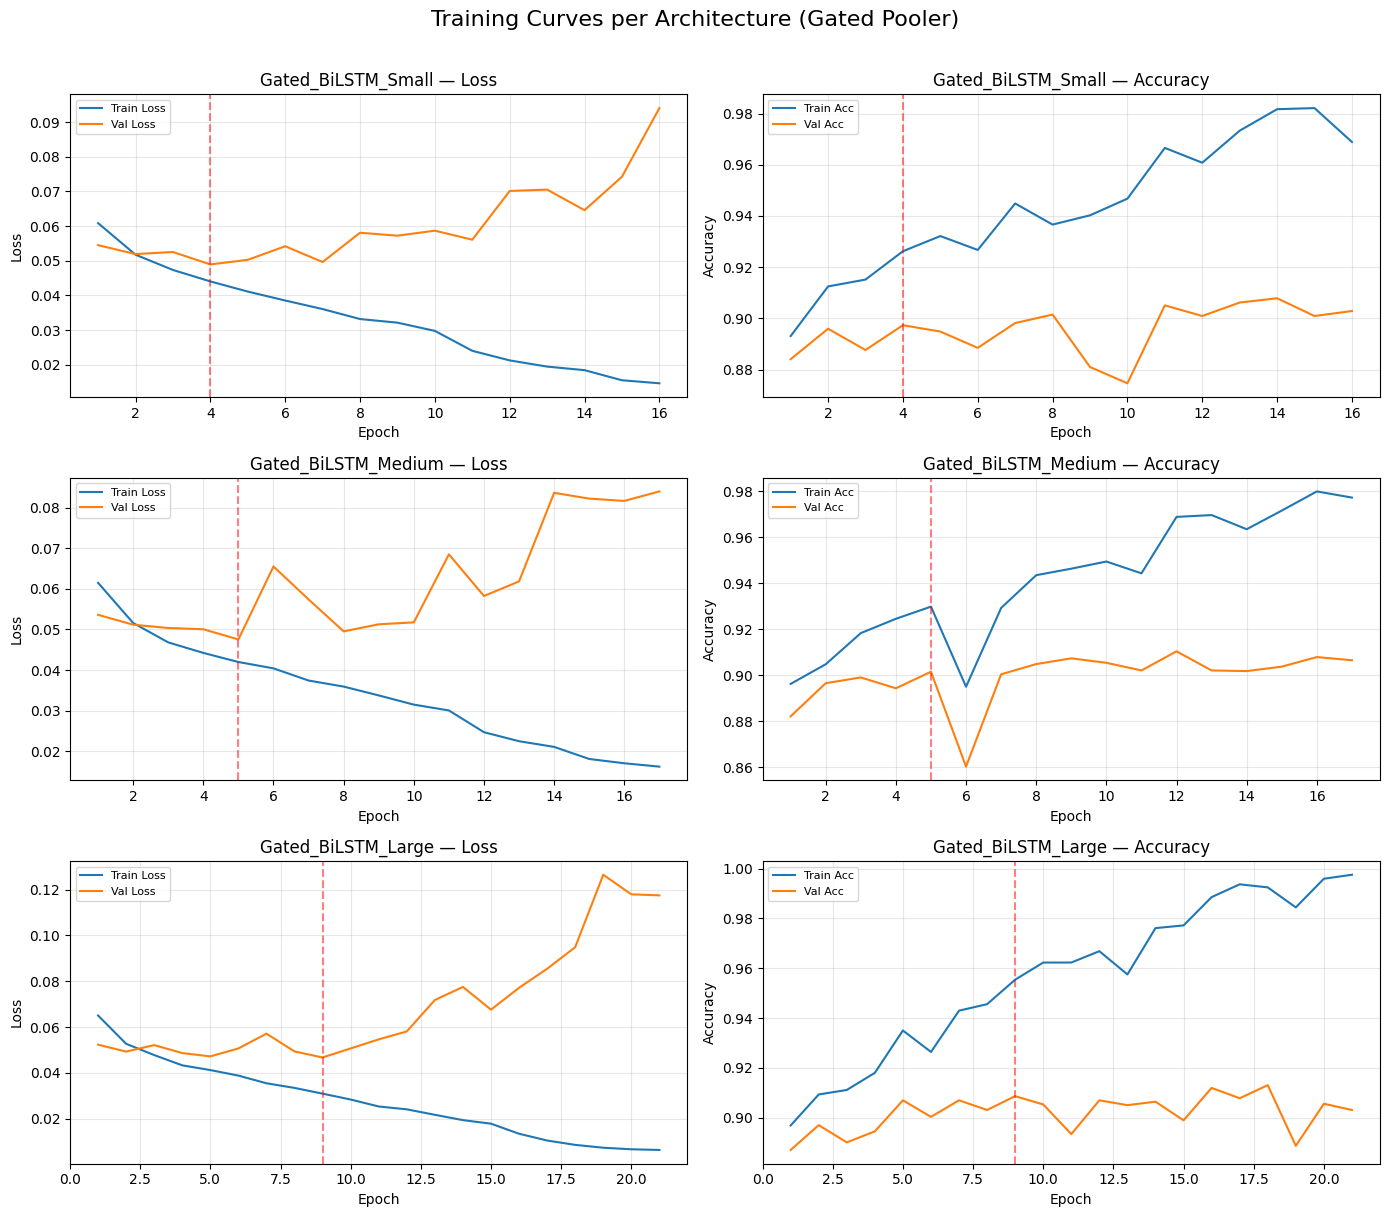

Saved: /kaggle/working/BiLSTM_Results/training_curves_individual.png


In [19]:
n_models = len(all_results)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 4 * n_models), squeeze=False)

for idx, r in enumerate(all_results):
    h = r["history"]
    epochs = h["epoch"]

    ax_loss = axes[idx, 0]
    ax_loss.plot(epochs, h["train_loss"], label="Train Loss", linewidth=1.5)
    ax_loss.plot(epochs, h["val_loss"], label="Val Loss", linewidth=1.5)
    ax_loss.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5)
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.set_title(f"{r['name']} — Loss")
    ax_loss.legend(fontsize=8)
    ax_loss.grid(True, alpha=0.3)

    ax_acc = axes[idx, 1]
    ax_acc.plot(epochs, h["train_acc"], label="Train Acc", linewidth=1.5)
    ax_acc.plot(epochs, h["val_acc"], label="Val Acc", linewidth=1.5)
    ax_acc.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5)
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_title(f"{r['name']} — Accuracy")
    ax_acc.legend(fontsize=8)
    ax_acc.grid(True, alpha=0.3)

fig.suptitle("Training Curves per Architecture (Gated Pooler)", fontsize=16, y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves_individual.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'training_curves_individual.png'}")

## 📈 Visualización: Curvas comparativas conjuntas

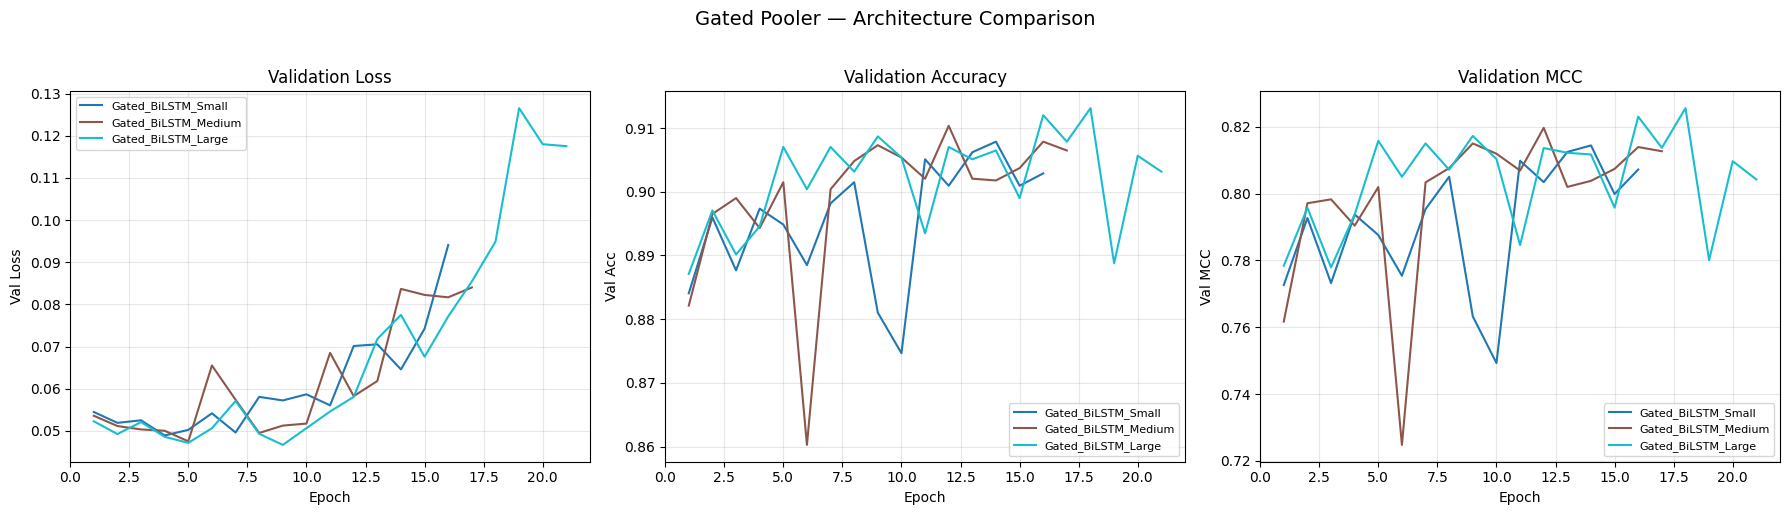

Saved: /kaggle/working/BiLSTM_Results/training_curves_comparison.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.tab10(np.linspace(0, 1, n_models))

for idx, r in enumerate(all_results):
    h = r["history"]
    axes[0].plot(h["epoch"], h["val_loss"], label=r["name"], color=colors[idx], linewidth=1.5)
    axes[1].plot(h["epoch"], h["val_acc"], label=r["name"], color=colors[idx], linewidth=1.5)
    axes[2].plot(h["epoch"], h["val_mcc"], label=r["name"], color=colors[idx], linewidth=1.5)

# Eje 0: Loss
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Val Loss"); axes[0].set_title("Validation Loss")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Eje 1: Accuracy
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val Acc"); axes[1].set_title("Validation Accuracy")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

# ✅ Eje 2: MCC 
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Val MCC"); axes[2].set_title("Validation MCC")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

fig.suptitle("Gated Pooler — Architecture Comparison", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'training_curves_comparison.png'}")

## 📊 Visualización: Gráfico de Barras Comparativo

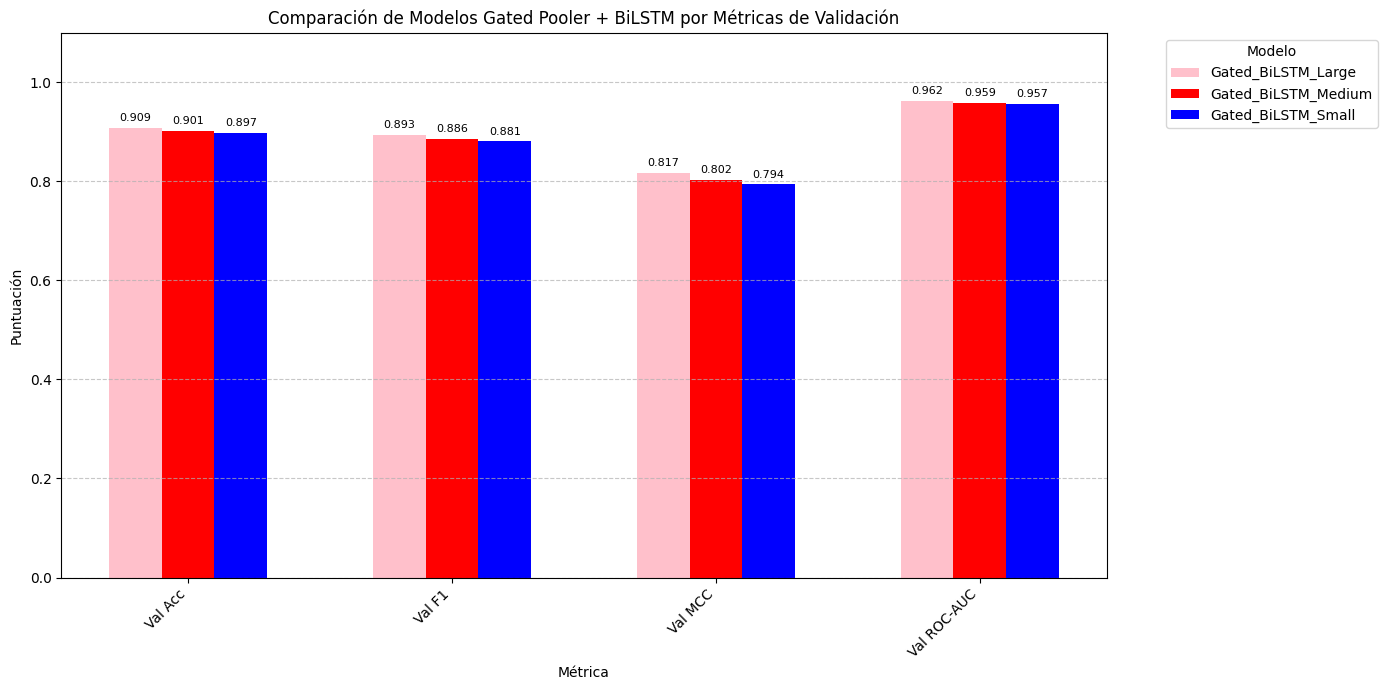

Saved: /kaggle/working/BiLSTM_Results/model_metrics_comparison_bar_chart.png


In [21]:
metric_cols = ["Val Acc", "Val F1", "Val MCC", "Val ROC-AUC"]
model_names = summary_df['Model'].tolist()

fig, ax = plt.subplots(figsize=(14, 7))
bar_width = 0.2
index = np.arange(len(metric_cols))
custom_colors = ['pink', 'red', 'blue', 'violet']

for i, model_name in enumerate(model_names):
    model_scores = summary_df[summary_df['Model'] == model_name][metric_cols].values.flatten()
    bars = ax.bar(index + i * bar_width, model_scores, bar_width, label=model_name, color=custom_colors[i % len(custom_colors)])
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 3),
                ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Métrica')
ax.set_ylabel('Puntuación')
ax.set_title('Comparación de Modelos Gated Pooler + BiLSTM por Métricas de Validación')
ax.set_xticks(index + bar_width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metric_cols, rotation=45, ha='right')
ax.set_ylim(0, 1.1)
ax.legend(title='Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plot_path = OUT_DIR / "model_metrics_comparison_bar_chart.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")

## 💾 Guardado del Mejor Modelo y Artefactos

In [22]:
best_model = best_result["model"]
best_config = best_result["config"]

val_proba_final, val_y_final = predict_proba(best_model, val_loader, DEVICE)
val_metrics_final = compute_metrics(val_y_final, val_proba_final)

final_ckpt_path = OUT_DIR / "best_model_final.pth"
final_checkpoint = {
    "model_name": best_config["name"],
    "state_dict": best_model.state_dict(),
    "config": best_config,
    "input_dim": INPUT_DIM,
    "n_params": best_result["n_params"],
    "best_epoch": best_result["best_epoch"],
    "best_val_loss": best_result["best_val_loss"],
    "training_time_sec": best_result["training_time_sec"],
    "val_metrics": val_metrics_final,
    "history": best_result["history"],
    "hyperparameters": {
        "seed": SEED,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,
        "lr": best_config["lr"],
        "weight_decay": best_config["weight_decay"],
    },
}
torch.save(final_checkpoint, final_ckpt_path)

history_df = pd.DataFrame(best_result["history"])
history_path = OUT_DIR / "best_model_training_log.csv"
history_df.to_csv(history_path, index=False)

metrics_path = OUT_DIR / "best_model_val_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(val_metrics_final, f, indent=2)

print(f"\n🏆 Best model: {best_config['name']}")
print(f"   Parameters: {best_result['n_params']:,}")
print(f"   Best epoch: {best_result['best_epoch']}")
print(f"   Val loss:   {best_result['best_val_loss']:.6f}")
print(f"\nSaved:")
print(f"  Checkpoint:    {final_ckpt_path}")
print(f"  Training log:  {history_path}")
print(f"  Val metrics:   {metrics_path}")


🏆 Best model: Gated_BiLSTM_Large
   Parameters: 13,200,450
   Best epoch: 9
   Val loss:   0.046697

Saved:
  Checkpoint:    /kaggle/working/BiLSTM_Results/best_model_final.pth
  Training log:  /kaggle/working/BiLSTM_Results/best_model_training_log.csv
  Val metrics:   /kaggle/working/BiLSTM_Results/best_model_val_metrics.json


# 🏁 Resumen del Pipeline de Entrenamiento BiLSTM | ProtFlash

Este notebook cierra la fase de **modelado secuencial**, evaluando sistemáticamente la capacidad de las arquitecturas LSTM (uni/bidireccionales) para capturar patrones en embeddings enriquecidos por pooling guiado de AAontology.

| 📦 Entregable | 📐 Formato | 📊 Volumen |
|:---|:---|:---|
| `checkpoint_*.pth` | PyTorch state dict + metadata | ✅ 4 modelos entrenados y validados |
| `architecture_comparison.csv` | Tabular | ✅ Métricas por modelo ordenadas por Val MCC |
| `training_curves_*.png` | Visualización | ✅ Curvas individuales, comparativas y barras |
| `best_model_final.pth` | Checkpoint optimizado | ✅ Mejor configuración: `Gated_BiLSTM_Large` (MCC: 0.8172) |

### 📌 Logros Clave
- **Enriquecimiento biológico**: El `GatedPooler` integra señales fisicoquímicas reales antes de la secuencia LSTM.
- **Entrenamiento estable**: `BCEWithLogitsLoss` + `pos_weight` + `ReduceLROnPlateau` + gradient clipping.
- **Comparación rigurosa**: Evaluación bajo misma semilla, datos y métricas robustas (MCC, PR-AUC) para desbalanceo real.